In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils
import nist_codes

try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [3]:
min_int = df_filtered['Grey Val'].min()
max_int = df_filtered['Grey Val'].max()
int_range = max_int - min_int

rgb = utils.wavelength_to_rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
dyn_prom = prominence * int_range
min_bright = 0.1
min_alpha = 0.1
x_min = 400
x_max = 750
mode = None

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [4]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        plt.grid(True)
    
    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [5]:
def line_plot_iteration():

    plt.figure(figsize=fig_size)    
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        # Use the normalized Grey Val of the first point in the segment for intensity
        int_factor = df_filtered.iloc[i]['Normalized_int']

        # Get base RGB color for the start wavelength
        base_rgb = rgb(wavelength_start)

        # Scale the intensity factor to ensure it ranges from min_brightness to 1.0
        final_intensity_scale = min_bright + (1 - min_bright) * int_factor

        colored_rgb = (base_rgb[0] * final_intensity_scale,
                    base_rgb[1] * final_intensity_scale,
                    base_rgb[2] * final_intensity_scale)

        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                color=colored_rgb,
                linewidth=2)
    

In [6]:
def filled_plot_iteration():

    plt.figure(figsize=fig_size) 
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        # Use the wavelength at the start of the segment for color mapping
        base_rgb = rgb(wavelength_start)

        # Use the normalized Grey Val of the first point in the segment for alpha (transparency)
        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        # Scale alpha factor: from min_alpha at lowest normalized intensity to 1.0 at highest
        final_alpha = min_alpha + (1 - min_alpha) * alpha_factor

        # Fill the area under the curve for this segment
        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                        color=base_rgb,
                        alpha=final_alpha,
                        linewidth=0) # No line for the fill edges

        # Plot the line on top for clarity, using the base color for the line itself
        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                color=base_rgb,
                linewidth=2) # Thicker line for better visibility on top of fill

In [7]:
def peak_labels():
    for peak_index in peaks:
        row = df_filtered.iloc[peak_index]
        plt.annotate(f"{row['nm']:.2f} nm", # Formatted nm to two decimal places
                    (row['nm'], row['Grey Val']),
                    textcoords="offset points", # Offset the text
                    xytext=(0,10), # Distance from point to label
                    ha='center', # Horizontal alignment
                    bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="b", lw=0.5, alpha=0.7),
                    arrowprops=dict(facecolor='black', shrink=0.05))

Calculated dynamic prominence: 27.39


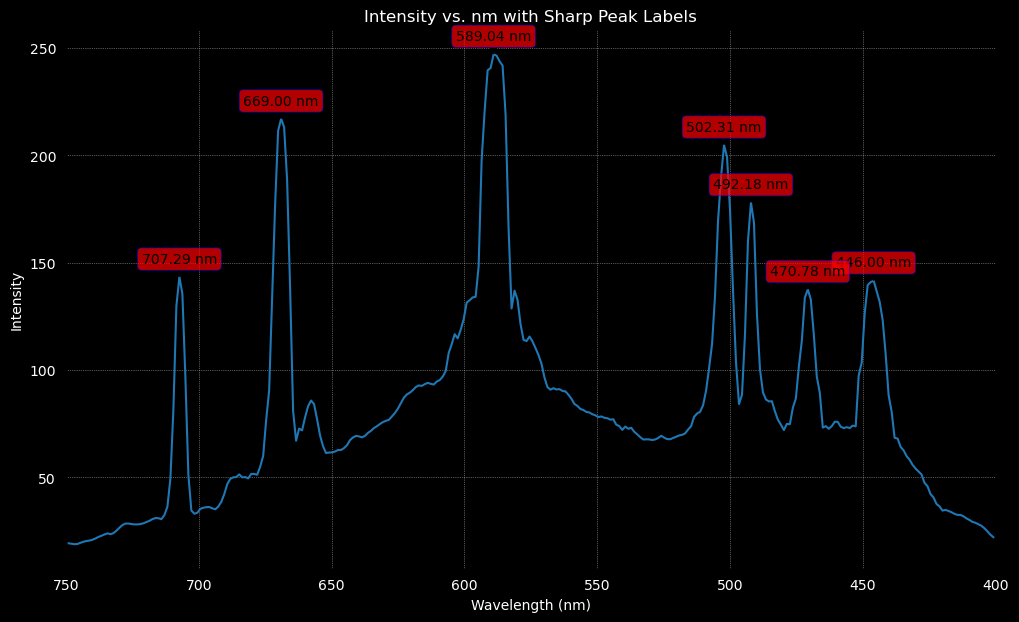

In [8]:
mode = 'dark'

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_filtered, x='nm', y='Grey Val', marker=None) 
plt.title('Intensity vs. nm with Sharp Peak Labels', color='white')

axis_labels()

# Set x-axis limits and reverse the order
plt.xlim(750, 400)

print(f"Calculated dynamic prominence: {dyn_prom:.2f}")
peaks, _ = find_peaks(df_filtered['Grey Val'], prominence=dyn_prom) 

# Label the identified sharp peaks
peak_labels()
plt.show()

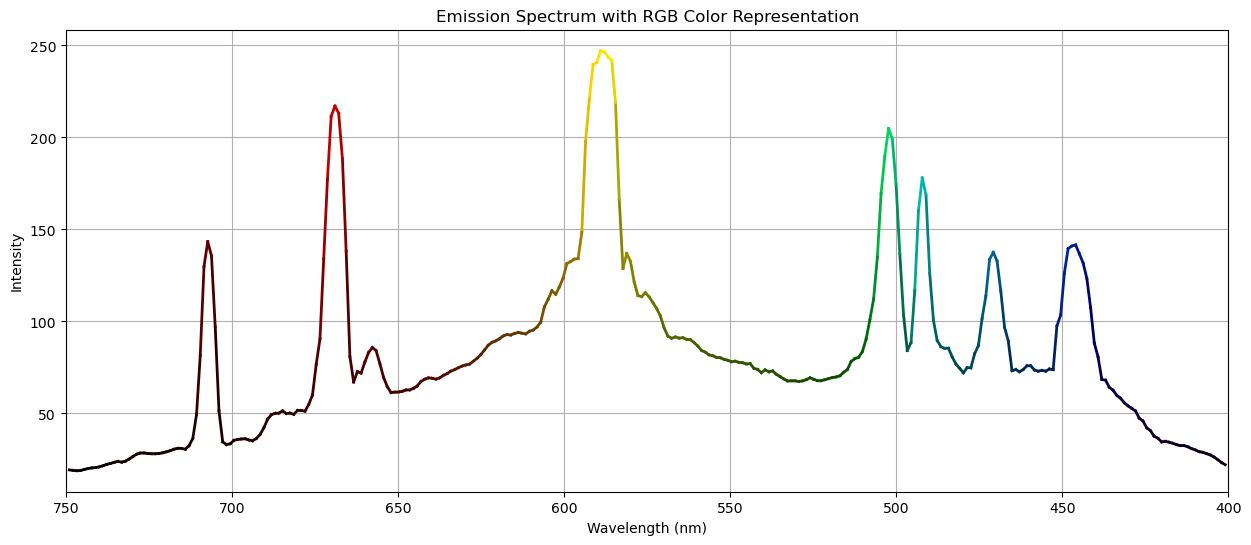

This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).
The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_int' adjusts the perceived brightness of these colors.


In [9]:
mode = 'light'
line_plot_iteration()

plt.title('Emission Spectrum with RGB Color Representation')

plt.xlim(750, 400)

plt.show()

print("This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).")
print("The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_int' adjusts the perceived brightness of these colors.")

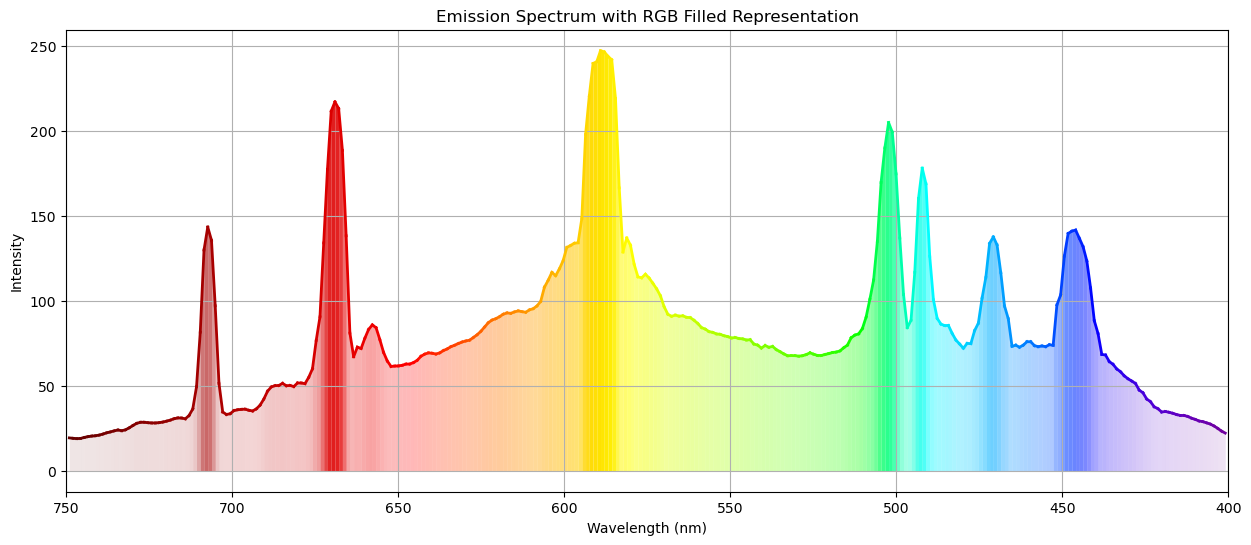

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.


In [10]:
filled_plot_iteration()

plt.title('Emission Spectrum with RGB Filled Representation')

plt.xlim(750, 400) 

plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.")

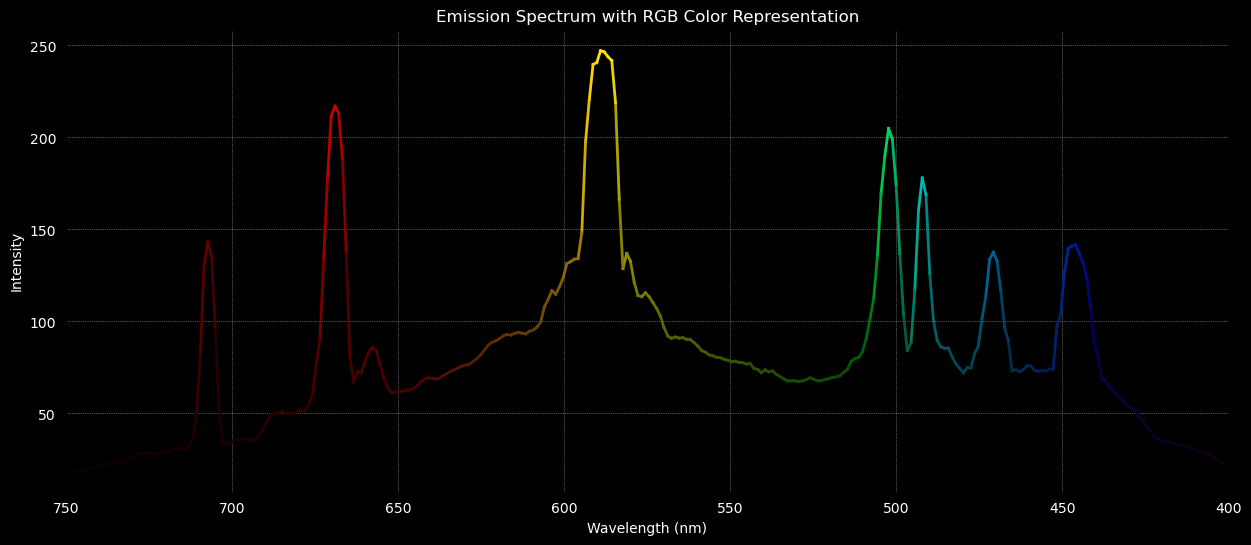

This plot displays the emission spectrum with a black background, using sharp, distinct lines.
The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.


In [11]:
mode = 'dark'

# Plot each segment with its corresponding RGB color and intensity
line_plot_iteration()

plt.title('Emission Spectrum with RGB Color Representation', color='white') # Set title color to white
plt.xlim(750, 400) # Keep x-axis reversed as per previous request

plt.show()

print("This plot displays the emission spectrum with a black background, using sharp, distinct lines.")
print("The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.")

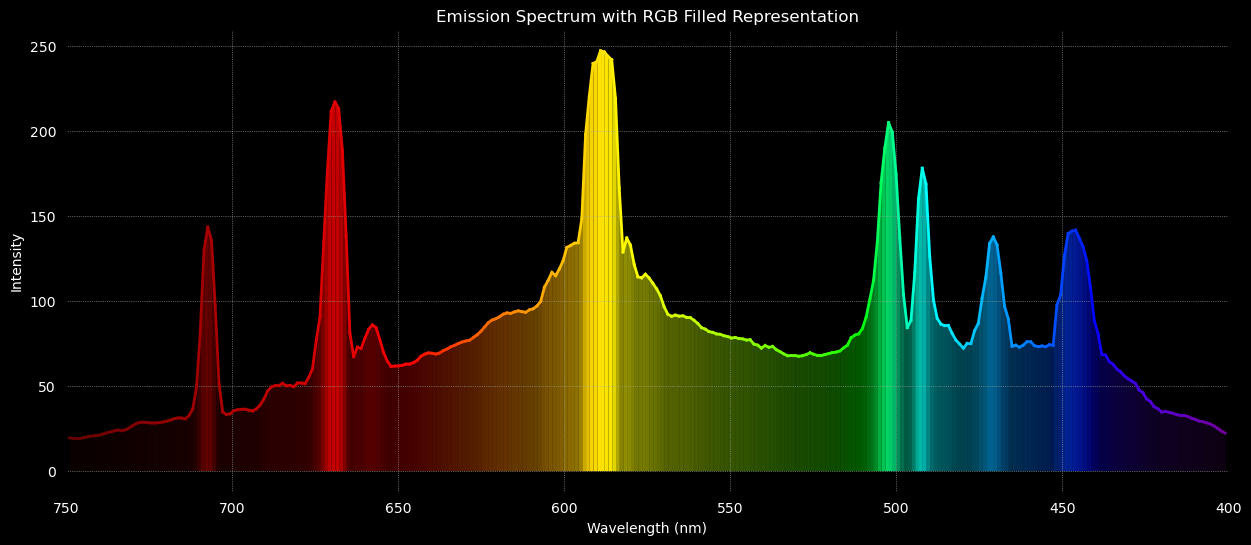

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.


In [12]:
mode = 'dark'

filled_plot_iteration()

plt.title('Emission Spectrum with RGB Filled Representation', color='white') # Set title color to white

plt.xlim(750, 400) # Keep x-axis reversed as per previous request

plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.")

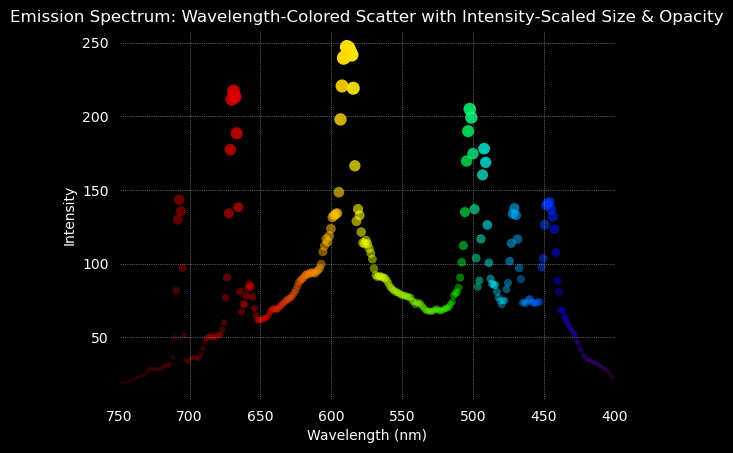

This visualization presents the emission spectrum as a scatter plot.
Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).
This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.


In [13]:
mode = 'dark'

axis_labels()

plt.xlim(750, 400) # Keep x-axis reversed as per previous request

# Prepare colors, sizes, and alphas for the scatter plot
# Scale marker size: from a base size (e.g., 5) to a max size (e.g., 100) based on normalized intensity
base_marker_size = 5
max_marker_size_factor = 95 # max_size = base_marker_size + max_marker_size_factor
sizes = base_marker_size + (max_marker_size_factor * df_filtered['Normalized_int'])

# Scale alpha (opacity)
min_alpha_scatter = 0.2 # Minimum transparency for low intensity points
alphas = min_alpha_scatter + (1 - min_alpha_scatter) * df_filtered['Normalized_int']

# Create RGBA tuples for each point
rgba_colors = []
for i in range(len(df_filtered)):
    wavelength = df_filtered.iloc[i]['nm']
    r, g, b = rgb(wavelength)
    a = alphas.iloc[i] # get the alpha for this point
    rgba_colors.append((r, g, b, a))

plt.scatter(
    x=df_filtered['nm'],
    y=df_filtered['Grey Val'],
    c=rgba_colors, # Use RGBA colors
    s=sizes,
    edgecolors='none', # No edge colors for the markers
    label='Emission Data'
)

plt.title('Emission Spectrum: Wavelength-Colored Scatter with Intensity-Scaled Size & Opacity', color='white')
plt.show()

print("This visualization presents the emission spectrum as a scatter plot.")
print("Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).")
print("This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.")

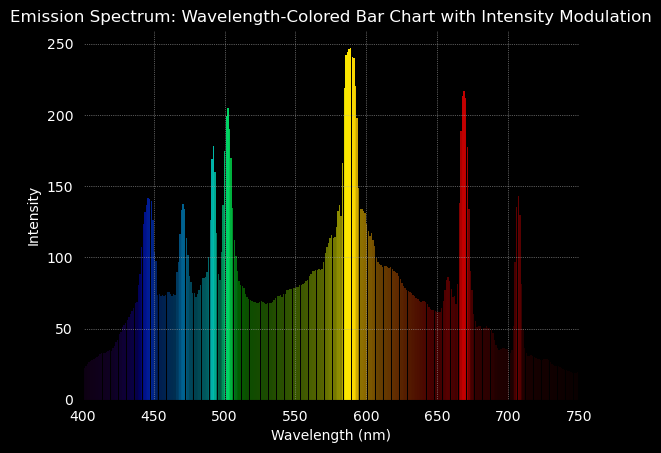

This visualization presents the emission spectrum as a bar chart.
Each bar's color is determined by its wavelength, and its brightness is scaled by its 'Grey Val' (intensity).
The bars represent discrete wavelength intervals, offering a block-like view of the spectrum.


In [14]:
mode = 'dark'
axis_labels()



# Set X-axis labels and color

plt.xlim(400, 750) # Set x-axis order from 400 to 750


# Prepare colors for each bar
bar_colors = []
min_brightness = 0.1 # Minimum brightness for any bar
for index, row in df_filtered.iterrows():
    wavelength = row['nm']
    normalized_intensity = row['Normalized_int']

    base_rgb = rgb(wavelength)

    # Scale the intensity factor for brightness
    final_intensity_scale = min_brightness + (1 - min_brightness) * normalized_intensity

    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    bar_colors.append(colored_rgb)

# Calculate bar widths. Assuming approximately even spacing for visualization.
# A fixed width might be simpler if exact binning is not required.
# Using a fixed width of 1nm for each bar, centered at the 'nm' value.
bar_width = 1

plt.bar(
    x=df_filtered['nm'],
    height=df_filtered['Grey Val'],
    width=bar_width,
    color=bar_colors,
    edgecolor='none' # No edge color for bars
)

plt.title('Emission Spectrum: Wavelength-Colored Bar Chart with Intensity Modulation', color='white')
plt.show()

print("This visualization presents the emission spectrum as a bar chart.")
print("Each bar's color is determined by its wavelength, and its brightness is scaled by its 'Grey Val' (intensity).")
print("The bars represent discrete wavelength intervals, offering a block-like view of the spectrum.")

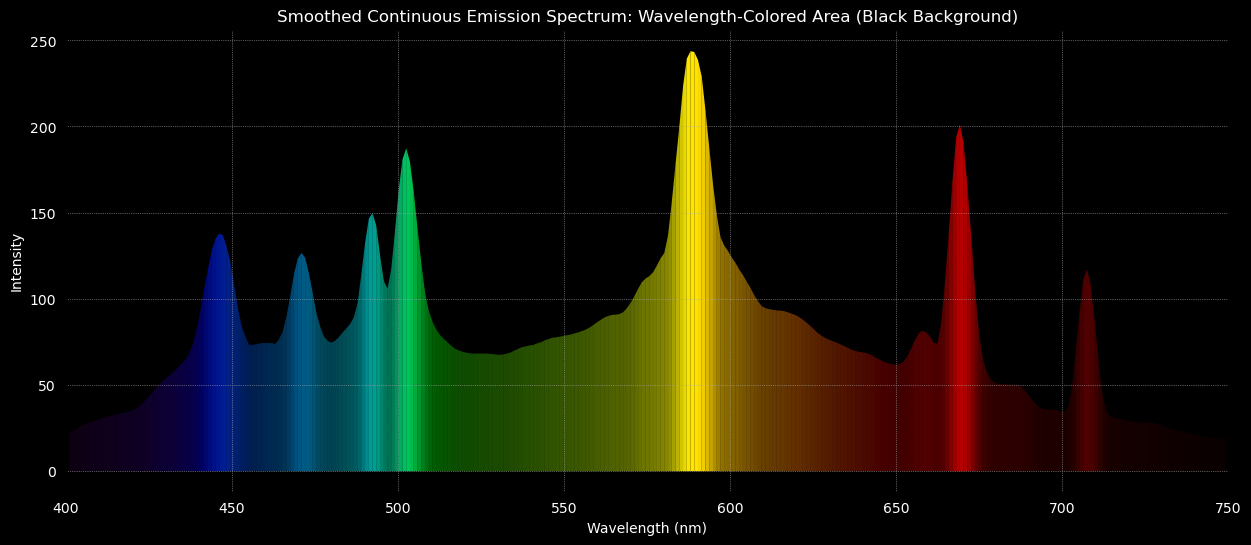

This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.
A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.
Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.


In [15]:
mode = 'dark'
plt.figure(figsize=fig_size)
axis_labels()


# Apply a rolling mean for smoothing
smoothing_window = 5 # Increased this value to control the degree of smoothing
df_filtered['Smoothed_int'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

# Normalize Smoothed_int for intensity scaling
min_int = df_filtered['Smoothed_int'].min()
max_int = df_filtered['Smoothed_int'].max()
int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range



plt.xlim(400, 750) # Set x-axis order from 400 to 750

# Iterate through each segment to apply specific color and alpha
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the wavelength at the start of the segment for color mapping
    base_rgb = rgb(wavelength_start)

    # Use the normalized Grey Val of the first point in the segment for alpha (transparency)
    # Scale alpha to ensure low intensity regions are still visible but fainter
    alpha_factor = df_filtered.iloc[i]['Normalized_int']

    # Scale alpha factor: from min_alpha at lowest normalized intensity to 1.0 at highest
    final_alpha = min_alpha + (1 - min_alpha) * alpha_factor

    # Fill the area under the curve for this segment using 'Smoothed_int'
    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_int'], df_filtered.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0) # No line for the fill edges

plt.title('Smoothed Continuous Emission Spectrum: Wavelength-Colored Area (Black Background)', color='white')
plt.show()

print("This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.")
print("A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.")
print("Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.")

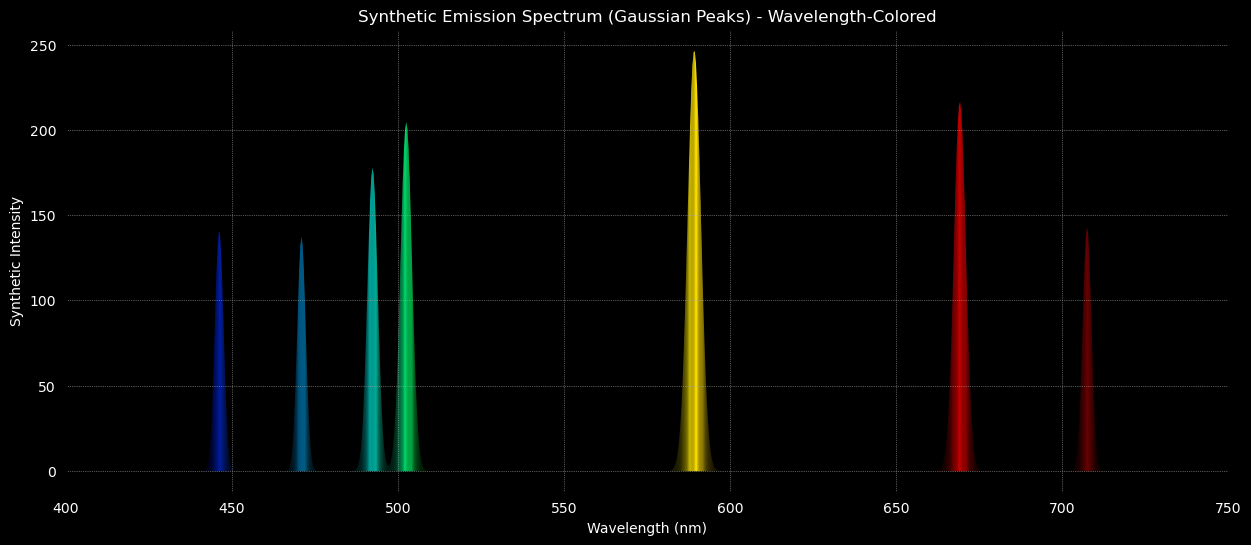

This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.
The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.
The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.


In [16]:
# --- Synthetic Spectrum (Gaussian Peaks) Visualization --- #

# Parameters for Gaussian synthesis
peak_prominence_threshold = 0.12 # Same as previous peak detection
gamma_factor = 0.8 # For rgb function

# Prepare data (filter and sort)
df_plot_data = df_filtered[(df_filtered['nm'] >= 400) & (df_filtered['nm'] <= 750)].copy()
df_plot_data = df_plot_data.sort_values(by='nm').reset_index(drop=True)

# Normalize 'Grey Val' for peak amplitude
min_intensity = df_plot_data['Grey Val'].min()
max_intensity = df_plot_data['Grey Val'].max()
intensity_range = max_intensity - min_intensity

if intensity_range == 0:
    df_plot_data['Normalized_Intensity'] = 1.0
else:
    df_plot_data['Normalized_Intensity'] = (df_plot_data['Grey Val'] - min_intensity) / intensity_range

# Detect peaks
dynamic_prominence = peak_prominence_threshold * intensity_range
peaks_indices, properties = find_peaks(df_plot_data['Grey Val'], prominence=dynamic_prominence)

# Create a new, denser wavelength array for plotting the synthetic spectrum
x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
y_synthetic = np.zeros_like(x_synthetic)

# Parameters for Gaussian widths (standard deviation)
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be

# Generate a sum of Gaussians for the synthetic spectrum
for i, peak_idx in enumerate(peaks_indices):
    peak_nm = df_plot_data.iloc[peak_idx]['nm']
    peak_amplitude = df_plot_data.iloc[peak_idx]['Grey Val']
    normalized_amplitude = df_plot_data.iloc[peak_idx]['Normalized_Intensity']

    # Scale sigma based on normalized intensity (higher intensity = broader peak)
    sigma = base_sigma_nm + (max_sigma_multiplier - 1) * base_sigma_nm * normalized_amplitude

    # Create a Gaussian curve for this peak
    gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
    y_synthetic += gaussian_curve # Add to the total synthetic spectrum

# Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
min_y_synthetic = y_synthetic.min()
max_y_synthetic = y_synthetic.max()
if (max_y_synthetic - min_y_synthetic) == 0:
    normalized_y_synthetic = np.ones_like(y_synthetic)
else:
    normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca()

ax.set_facecolor('black')
plt.gcf().set_facecolor('black')

plt.xlabel('Wavelength (nm)', color='white')
plt.ylabel('Synthetic Intensity', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.xlim(400, 750)
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5)

# Iterate through each segment of the synthetic spectrum to apply color and alpha
for i in range(len(x_synthetic) - 1):
    wavelength_start = x_synthetic[i]
    wavelength_end = x_synthetic[i+1]

    base_rgb = rgb(wavelength_start, gamma=gamma_factor)

    # Scale alpha by normalized synthetic intensity
    # A base alpha ensures even low intensity regions are visible
    final_alpha = min_alpha + (1 - min_alpha) * normalized_y_synthetic[i]

    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0],
                     [y_synthetic[i], y_synthetic[i+1]],
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0)

plt.title('Synthetic Emission Spectrum (Gaussian Peaks) - Wavelength-Colored', color='white')
plt.show()

print("This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.")
print("The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.")
print("The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.")

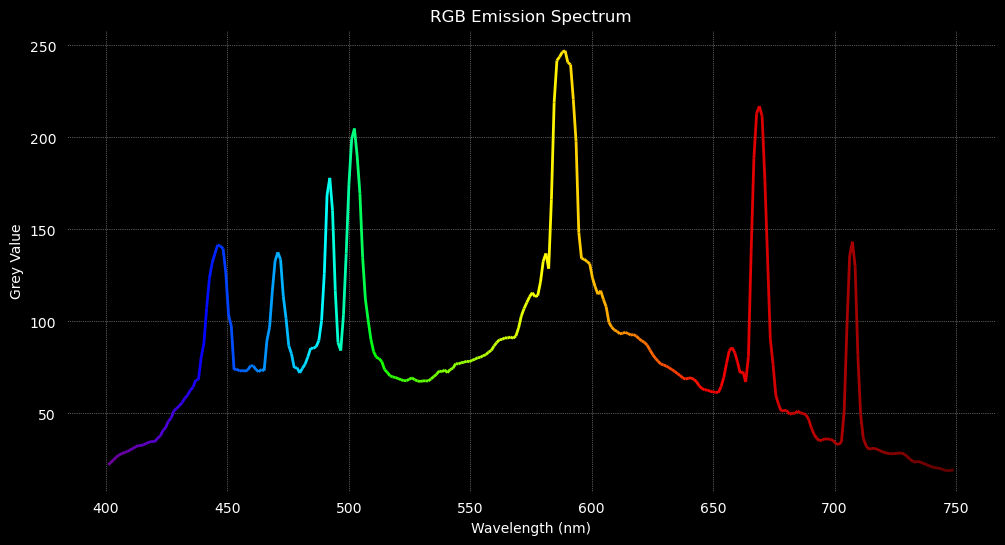

In [17]:
def rgb(wavelength, gamma=0.8):
    """
    Converts a wavelength (nm) to an RGB color.
    Based on code by Dan Bruton (bruton@tamu.edu)
    http://www.physics.sfasu.edu/astro/color/spectra.html
    """
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = (1.0) ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B)

# Apply the function to the 'nm' column to get RGB colors for each data point
colors = [rgb(nm) for nm in df_filtered['nm']]

# Prepare data for LineCollection
x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create segments for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection with the calculated colors
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.add_collection(lc)
ax.autoscale()
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_facecolor('black')
plt.gcf().set_facecolor('black')
ax.set_ylabel('Grey Value', color='white')
ax.set_title('RGB Emission Spectrum', color='white')
ax.grid(True, color='darkgrey', linestyle=':', linewidth=0.5)
plt.show()

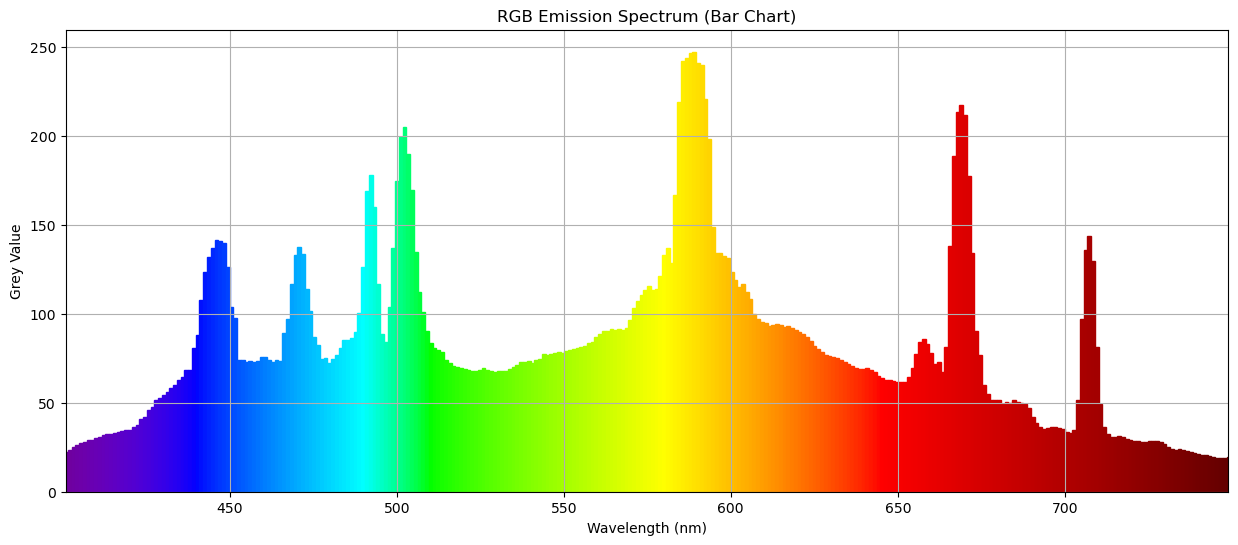

In [18]:
# Assuming df_filtered and colors (from rgb) are available from previous cells

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create a bar chart with colors corresponding to the wavelength
plt.figure(figsize=(15, 6))
# Use a small width for the bars to make it look continuous
bar_width = np.diff(x).mean() if len(x) > 1 else 1

for i in range(len(x)):
    plt.bar(x[i], y[i], color=colors[i], width=bar_width, edgecolor=colors[i])

plt.xlabel('Wavelength (nm)')
plt.ylabel('Grey Value')
plt.title('RGB Emission Spectrum (Bar Chart)')
plt.grid(True)
plt.xlim(x.min(), x.max()) # Ensure x-axis limits match data range
plt.show()

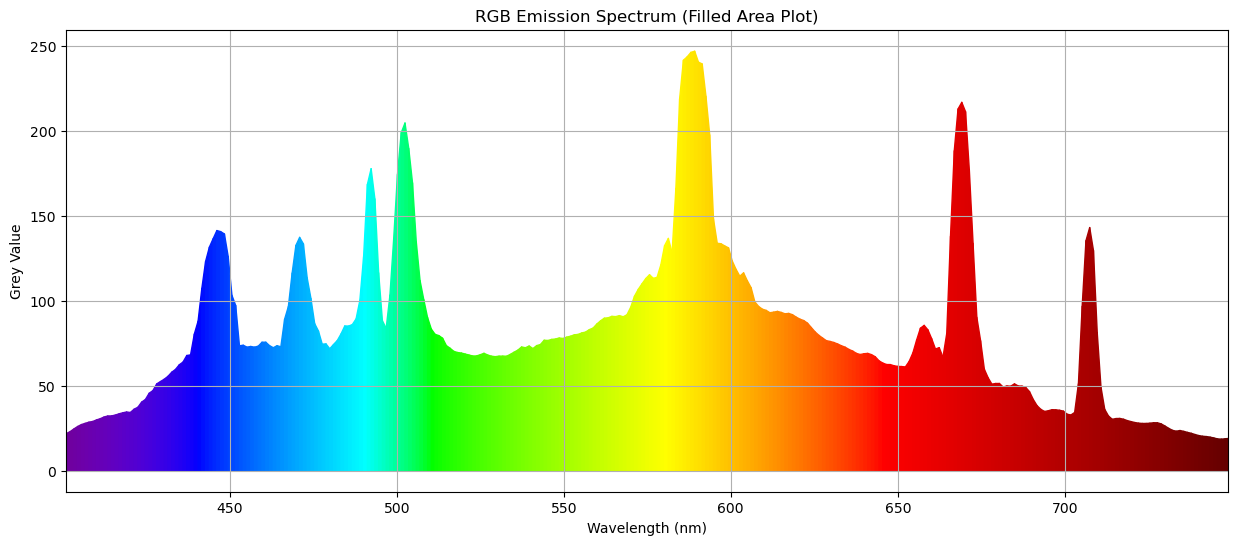

In [19]:
# Assuming df_filtered and colors (from rgb) are available from previous cells

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create a colormap from the generated RGB colors
# Need to normalize the colors to be from 0 to 1 for the colormap to work correctly with x_normalized
normalized_colors = [(c[0], c[1], c[2]) for c in colors]

# Create a custom colormap from the list of RGB colors
cmap = LinearSegmentedColormap.from_list("spectrum_cmap", normalized_colors, N=len(x))

# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Create a normalized version of x for the colormap mapping
x_normalized = (x - x.min()) / (x.max() - x.min())

# Fill the area under the curve with the custom colormap
for i in range(len(x) - 1):
    ax.fill_between(x[i:i+2], y[i:i+2], color=cmap(x_normalized[i]))

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Grey Value')
ax.set_title('RGB Emission Spectrum (Filled Area Plot)')
ax.grid(True)
ax.set_xlim(x.min(), x.max())
plt.show()